In [ ]:
#Environment Setup
!pip install -q -U transformers accelerate peft bitsandbytes datasets evaluate trl
!pip install -q -U scikit-learn

import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.9 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4


In [ ]:
from datasets import load_dataset

# AG News: 4 classes - World(0), Sports(1), Business(2), Sci/Tech(3)
raw_dataset = load_dataset("fancyzhx/ag_news")
print(raw_dataset)

label_names = ["World", "Sports", "Business", "Sci/Tech"]

# Use a SMALL subset for Colab T4 feasibility (full train set is 120k rows)
train_subset = raw_dataset["train"].shuffle(seed=42).select(range(2000))   # fine-tuning data
eval_subset  = raw_dataset["test"].shuffle(seed=42).select(range(300))     # accuracy comparison set

print(train_subset[0])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}


In [ ]:
import logging
import warnings

# Silence the repetitive transformers generation warning
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*max_new_tokens.*max_length.*")

In [ ]:
PROMPT_TEMPLATE = """Classify the following news article into one of these categories: World, Sports, Business, Sci/Tech.

Article: {text}
Category:"""

def format_prompt(example):
    return PROMPT_TEMPLATE.format(text=example["text"])

# For training, we need prompt + answer together
def format_training_example(example):
    prompt = format_prompt(example)
    answer = " " + label_names[example["label"]]
    return {"text": prompt + answer}

train_formatted = train_subset.map(format_training_example)
print(train_formatted[0]["text"])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Classify the following news article into one of these categories: World, Sports, Business, Sci/Tech.

Article: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.
Category: World


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)
base_model.eval()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [ ]:
def predict_label(model, tokenizer, text, max_new_tokens=5):
    prompt = format_prompt({"text": text})
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,            # greedy decoding for reproducibility
            pad_token_id=tokenizer.pad_token_id,
        )
    generated = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return generated.strip()

def parse_label(generated_text):
    """Map generated text to one of the 4 labels (simple substring match)."""
    generated_lower = generated_text.lower()
    for idx, name in enumerate(label_names):
        if name.lower() in generated_lower:
            return idx
    return -1  # unparseable / wrong format

def evaluate_model(model, tokenizer, eval_data):
    correct = 0
    total = len(eval_data)
    preds = []
    for example in eval_data:
        gen = predict_label(model, tokenizer, example["text"])
        pred_label = parse_label(gen)
        preds.append(pred_label)
        if pred_label == example["label"]:
            correct += 1
    accuracy = correct / total
    return accuracy, preds

base_accuracy, base_preds = evaluate_model(base_model, tokenizer, eval_subset)
print(f"Base model zero-shot accuracy: {base_accuracy:.4f}")

Base model zero-shot accuracy: 0.3667


In [ ]:
del base_model
torch.cuda.empty_cache()

In [ ]:
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.0 MB/s eta 0:00:00


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments
from trl import SFTTrainer, SFTConfig

# Reload model in fp16 (no quantization) for standard LoRA
lora_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)

lora_config = LoraConfig(
    r=8,                          # rank of the low-rank decomposition
    lora_alpha=16,                # scaling factor
    target_modules=["q_proj", "v_proj"],   # apply LoRA to attention projections
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

lora_model = get_peft_model(lora_base_model, lora_config)
lora_model.print_trainable_parameters()
# Expect something like: trainable params: ~1-2M || all params: ~1.1B || trainable%: ~0.1-0.2%

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [ ]:
sft_config = SFTConfig(
    output_dir="/content/lora_out",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    max_length=256,
    dataset_text_field="text",
)

lora_trainer = SFTTrainer(
    model=lora_model,
    args=sft_config,
    train_dataset=train_formatted,
    processing_class=tokenizer
)

lora_trainer.train()

/tmp/ipykernel_799/2495780288.py:1: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config = SFTConfig(


Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'loss': '2.51', 'grad_norm': '1.446', 'learning_rate': '0.0001928', 'entropy': '2.178', 'mean_token_accuracy': '0.5302', 'num_tokens': '1.564e+04', 'epoch': '0.08'}
{'loss': '2.036', 'grad_norm': '1.923', 'learning_rate': '0.0001848', 'entropy': '2.103', 'mean_token_accuracy': '0.6101', 'num_tokens': '3.104e+04', 'epoch': '0.16'}
{'loss': '1.681', 'grad_norm': '1.018', 'learning_rate': '0.0001768', 'entropy': '1.693', 'mean_token_accuracy': '0.6709', 'num_tokens': '4.655e+04', 'epoch': '0.24'}
{'loss': '1.571', 'grad_norm': '0.9416', 'learning_rate': '0.0001688', 'entropy': '1.552', 'mean_token_accuracy': '0.6833', 'num_tokens': '6.197e+04', 'epoch': '0.32'}
{'loss': '1.585', 'grad_norm': '0.8367', 'learning_rate': '0.0001608', 'entropy': '1.54', 'mean_token_accuracy': '0.6892', 'num_tokens': '7.781e+04', 'epoch': '0.4'}
{'loss': '1.554', 'grad_norm': '0.8075', 'learning_rate': '0.0001528', 'entropy': '1.529', 'mean_token_accuracy': '0.6906', 'num_tokens': '9.346e+04', 'epoch': '0.48'

TrainOutput(global_step=250, training_loss=1.569501594543457, metrics={'train_runtime': 252.0946, 'train_samples_per_second': 15.867, 'train_steps_per_second': 0.992, 'train_loss': 1.569501594543457, 'epoch': 2.0})

In [ ]:
lora_model.eval()
lora_accuracy, lora_preds = evaluate_model(lora_model, tokenizer, eval_subset)
print(f"LoRA fine-tuned accuracy: {lora_accuracy:.4f}")

LoRA fine-tuned accuracy: 0.8633


In [ ]:
del lora_model, lora_base_model, lora_trainer
torch.cuda.empty_cache()

In [ ]:
from transformers import BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",           # normalized float 4 — QLoRA's key innovation
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,      # quantize the quantization constants too
)

qlora_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

qlora_base_model = prepare_model_for_kbit_training(qlora_base_model)

qlora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

qlora_model = get_peft_model(qlora_base_model, qlora_config)
qlora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [ ]:
sft_config_qlora = SFTConfig(
    output_dir="/content/qlora_out",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=False,
    bf16=False,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    max_length=256,
    dataset_text_field="text",
    optim="paged_adamw_8bit",   # memory-efficient optimizer, standard for QLoRA
)

qlora_trainer = SFTTrainer(
    model=qlora_model,
    args=sft_config_qlora,
    train_dataset=train_formatted,
    processing_class=tokenizer,
)

qlora_trainer.train()

/tmp/ipykernel_799/3853571293.py:1: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config_qlora = SFTConfig(


{'loss': '2.52', 'grad_norm': '1.391', 'learning_rate': '0.0001928', 'entropy': '2.321', 'mean_token_accuracy': '0.5133', 'num_tokens': '1.564e+04', 'epoch': '0.08'}
{'loss': '2.04', 'grad_norm': '1.289', 'learning_rate': '0.0001848', 'entropy': '2.114', 'mean_token_accuracy': '0.6101', 'num_tokens': '3.104e+04', 'epoch': '0.16'}
{'loss': '1.755', 'grad_norm': '0.957', 'learning_rate': '0.0001768', 'entropy': '1.786', 'mean_token_accuracy': '0.6654', 'num_tokens': '4.655e+04', 'epoch': '0.24'}
{'loss': '1.683', 'grad_norm': '0.8359', 'learning_rate': '0.0001688', 'entropy': '1.664', 'mean_token_accuracy': '0.6727', 'num_tokens': '6.197e+04', 'epoch': '0.32'}
{'loss': '1.698', 'grad_norm': '0.8008', 'learning_rate': '0.0001608', 'entropy': '1.675', 'mean_token_accuracy': '0.6711', 'num_tokens': '7.781e+04', 'epoch': '0.4'}
{'loss': '1.647', 'grad_norm': '0.9258', 'learning_rate': '0.0001528', 'entropy': '1.656', 'mean_token_accuracy': '0.673', 'num_tokens': '9.346e+04', 'epoch': '0.48'}

TrainOutput(global_step=250, training_loss=1.6071943511962892, metrics={'train_runtime': 429.9923, 'train_samples_per_second': 9.302, 'train_steps_per_second': 0.581, 'train_loss': 1.6071943511962892, 'epoch': 2.0})

In [ ]:
qlora_model.eval()
qlora_accuracy, qlora_preds = evaluate_model(qlora_model, tokenizer, eval_subset)
print(f"QLoRA fine-tuned accuracy: {qlora_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


QLoRA fine-tuned accuracy: 0.8567


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Base (zero-shot)", "LoRA", "QLoRA"],
    "Accuracy": [base_accuracy, lora_accuracy, qlora_accuracy],
})
print(results)
results.to_csv("/content/results.csv", index=False)

             Method  Accuracy
0  Base (zero-shot)  0.366667
1              LoRA  0.863333
2             QLoRA  0.856667


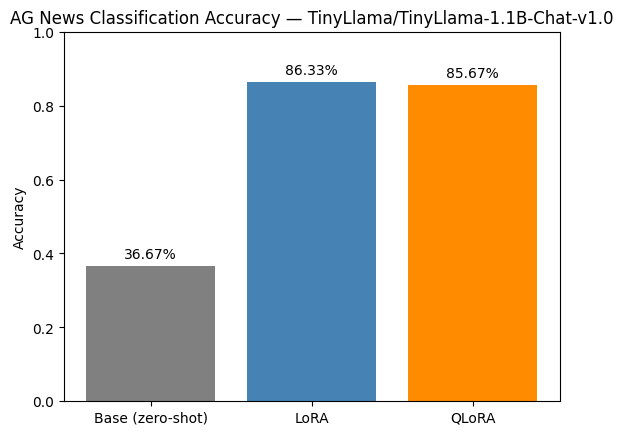

In [ ]:
import matplotlib.pyplot as plt

plt.bar(results["Method"], results["Accuracy"], color=["gray", "steelblue", "darkorange"])
plt.ylabel("Accuracy")
plt.title(f"AG News Classification Accuracy — {MODEL_NAME}")
plt.ylim(0, 1)
for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center")
plt.show()